In [45]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from pathlib import Path

# Load eval log
REPORT_DIR = Path(r"D:\nanochat_model\1950_1999\report_new1")
records = []
with open(REPORT_DIR / "eval_log.jsonl") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

df = pd.DataFrame(records)
print(f"Total eval points: {len(df)}")
df.head()

Total eval points: 70


,timestamp,label,source,model_tag,HellaSwag,HellaSwag_detail,Winogrande,Winogrande_detail,PIQA,PIQA_detail,RACE-Middle,RACE-Middle_detail,RACE-High,RACE-High_detail,LAB,LAB_detail
0,2026-02-18 09:02:07,mid_01: hist_economist,mid,mid_01,0.252930,259/1024,0.504883,517/1024,0.505859,518/1024,0.299805,307/1024,0.288086,295/1024,0.267578,274/1024
1,2026-02-18 09:03:13,mid_02: hist_nyt_filtered,mid,mid_02,0.273438,280/1024,0.502930,515/1024,0.505859,518/1024,0.327148,335/1024,0.305664,313/1024,0.273438,280/1024
2,2026-02-18 09:04:17,mid_03: hist_ft,mid,mid_03,0.275391,282/1024,0.503906,516/1024,0.505859,518/1024,0.358398,367/1024,0.323242,331/1024,0.271484,278/1024
3,2026-02-18 09:05:20,mid_04: hist_newswire,mid,mid_04,0.287109,294/1024,0.504883,517/1024,0.504883,517/1024,0.445312,456/1024,0.384766,394/1024,0.314453,322/1024
4,2026-02-18 09:05:48,mid_05: hist_US-PD-Newspapers,mid,mid_05,0.286133,293/1024,0.503906,516/1024,0.506836,519/1024,0.456055,467/1024,0.393555,403/1024,0.329102,337/1024


In [46]:
df.to_csv(REPORT_DIR / 'df.csv')

In [47]:
REPORT_DIR

WindowsPath('D:/nanochat_model/1950_1999/report_new1')

In [48]:
# Filter to sequential evals only (mid_XX and sft_XX, drop sft_final)
df_seq = df[df["model_tag"].str.match(r"^(mid|sft)_\d+$", na=False)].copy()
df_seq = df_seq.reset_index(drop=True)

# Add sequential index
df_seq["eval_idx"] = range(len(df_seq))

# Extract phase number
df_seq["phase_num"] = df_seq["model_tag"].str.extract(r"_(\d+)$").astype(int)

# Benchmark columns — include RACE if present in data
BENCHMARKS_BASE = ["HellaSwag", "Winogrande", "PIQA"]
BENCHMARKS_RACE = ["RACE-Middle", "RACE-High"]
BENCHMARKS = BENCHMARKS_BASE + [b for b in BENCHMARKS_RACE if b in df_seq.columns]

print(f"Sequential eval points: {len(df_seq)}")
print(f"Mid-training: {len(df_seq[df_seq['source'] == 'mid'])}")
print(f"SFT: {len(df_seq[df_seq['source'] == 'sft'])}")
print(f"Benchmarks tracked: {BENCHMARKS}")
df_seq[["label", "source", "model_tag"] + BENCHMARKS + ["LAB"]].tail(10)

Sequential eval points: 70
Mid-training: 35
SFT: 35
Benchmarks tracked: ['HellaSwag', 'Winogrande', 'PIQA', 'RACE-Middle', 'RACE-High']


,label,source,model_tag,HellaSwag,Winogrande,PIQA,RACE-Middle,RACE-High,LAB
60,sft_27: logiqa,sft,sft_27,0.288086,0.505859,0.555664,0.646484,0.535156,0.335938
61,sft_28: scienceqa,sft,sft_28,0.285156,0.508789,0.556641,0.641602,0.531250,0.334961
62,sft_29: arc_easy,sft,sft_29,0.286133,0.506836,0.557617,0.643555,0.534180,0.335938
63,sft_30: arc_challenge,sft,sft_30,0.286133,0.504883,0.550781,0.644531,0.533203,0.332031
64,sft_31: hotpotqa,sft,sft_31,0.288086,0.518555,0.552734,0.644531,0.536133,0.329102
65,sft_32: musique,sft,sft_32,0.291016,0.515625,0.553711,0.647461,0.539062,0.325195
66,sft_33: strategyqa,sft,sft_33,0.291992,0.519531,0.551758,0.646484,0.538086,0.330078
67,sft_34: codecontests,sft,sft_34,0.294922,0.518555,0.550781,0.650391,0.537109,0.329102
68,sft_35: mbpp,sft,sft_35,0.289062,0.516602,0.547852,0.646484,0.537109,0.328125
69,sft_36: humaneval,sft,sft_36,0.289062,0.511719,0.548828,0.651367,0.535156,0.327148


In [49]:
# Define domain groups and their index ranges within each phase (mid / sft)
# These map to the dataset ordering in speedrun_hist_llm.sh (36 datasets per phase)

DOMAIN_GROUPS = [
    # (label, color, mid range, sft range)
    ("News",         "#1f77b4", (1, 6),   (1, 6)),
    ("Legal",        "#ff7f0e", (7, 11),  (7, 11)),
    ("Books",        "#2ca02c", (12, 16), (12, 16)),
    ("Science",      "#d62728", (17, 20), (17, 20)),
    ("General",      "#9467bd", (21, 22), (21, 22)),
    ("Math",         "#8c564b", (23, 25), (23, 25)),
    ("Logic",        "#e377c2", (26, 27), (26, 27)),
    ("Science Bench","#7f7f7f", (28, 30), (28, 30)),
    ("Multi-hop",    "#17becf", (31, 33), (31, 33)),
    ("Code",         "#aec7e8", (34, 36), (34, 36)),
]

def get_group_color(source, phase_num):
    for label, color, mid_range, sft_range in DOMAIN_GROUPS:
        r = mid_range if source == "mid" else sft_range
        if r[0] <= phase_num <= r[1]:
            return color, label
    return "#333333", "Other"

df_seq["color"] = df_seq.apply(lambda row: get_group_color(row["source"], row["phase_num"])[0], axis=1)
df_seq["domain"] = df_seq.apply(lambda row: get_group_color(row["source"], row["phase_num"])[1], axis=1)

# Prefix domain with phase
df_seq["phase_domain"] = df_seq.apply(
    lambda row: f"{row['source'].upper()} {row['domain']}", axis=1
)

df_seq[["label", "phase_domain", "color"]].head(10)

,label,phase_domain,color
0,mid_01: hist_economist,MID News,#1f77b4
1,mid_02: hist_nyt_filtered,MID News,#1f77b4
2,mid_03: hist_ft,MID News,#1f77b4
3,mid_04: hist_newswire,MID News,#1f77b4
4,mid_05: hist_US-PD-Newspapers,MID News,#1f77b4
5,mid_06: hist_French-PD-Newspapers,MID News,#1f77b4
6,mid_07: hist_Caselaw_Access_Project,MID Legal,#ff7f0e
7,mid_08: hist_USPTO,MID Legal,#ff7f0e
8,mid_09: hist_GATT_library,MID Legal,#ff7f0e
9,mid_10: hist_Eurlex,MID Legal,#ff7f0e


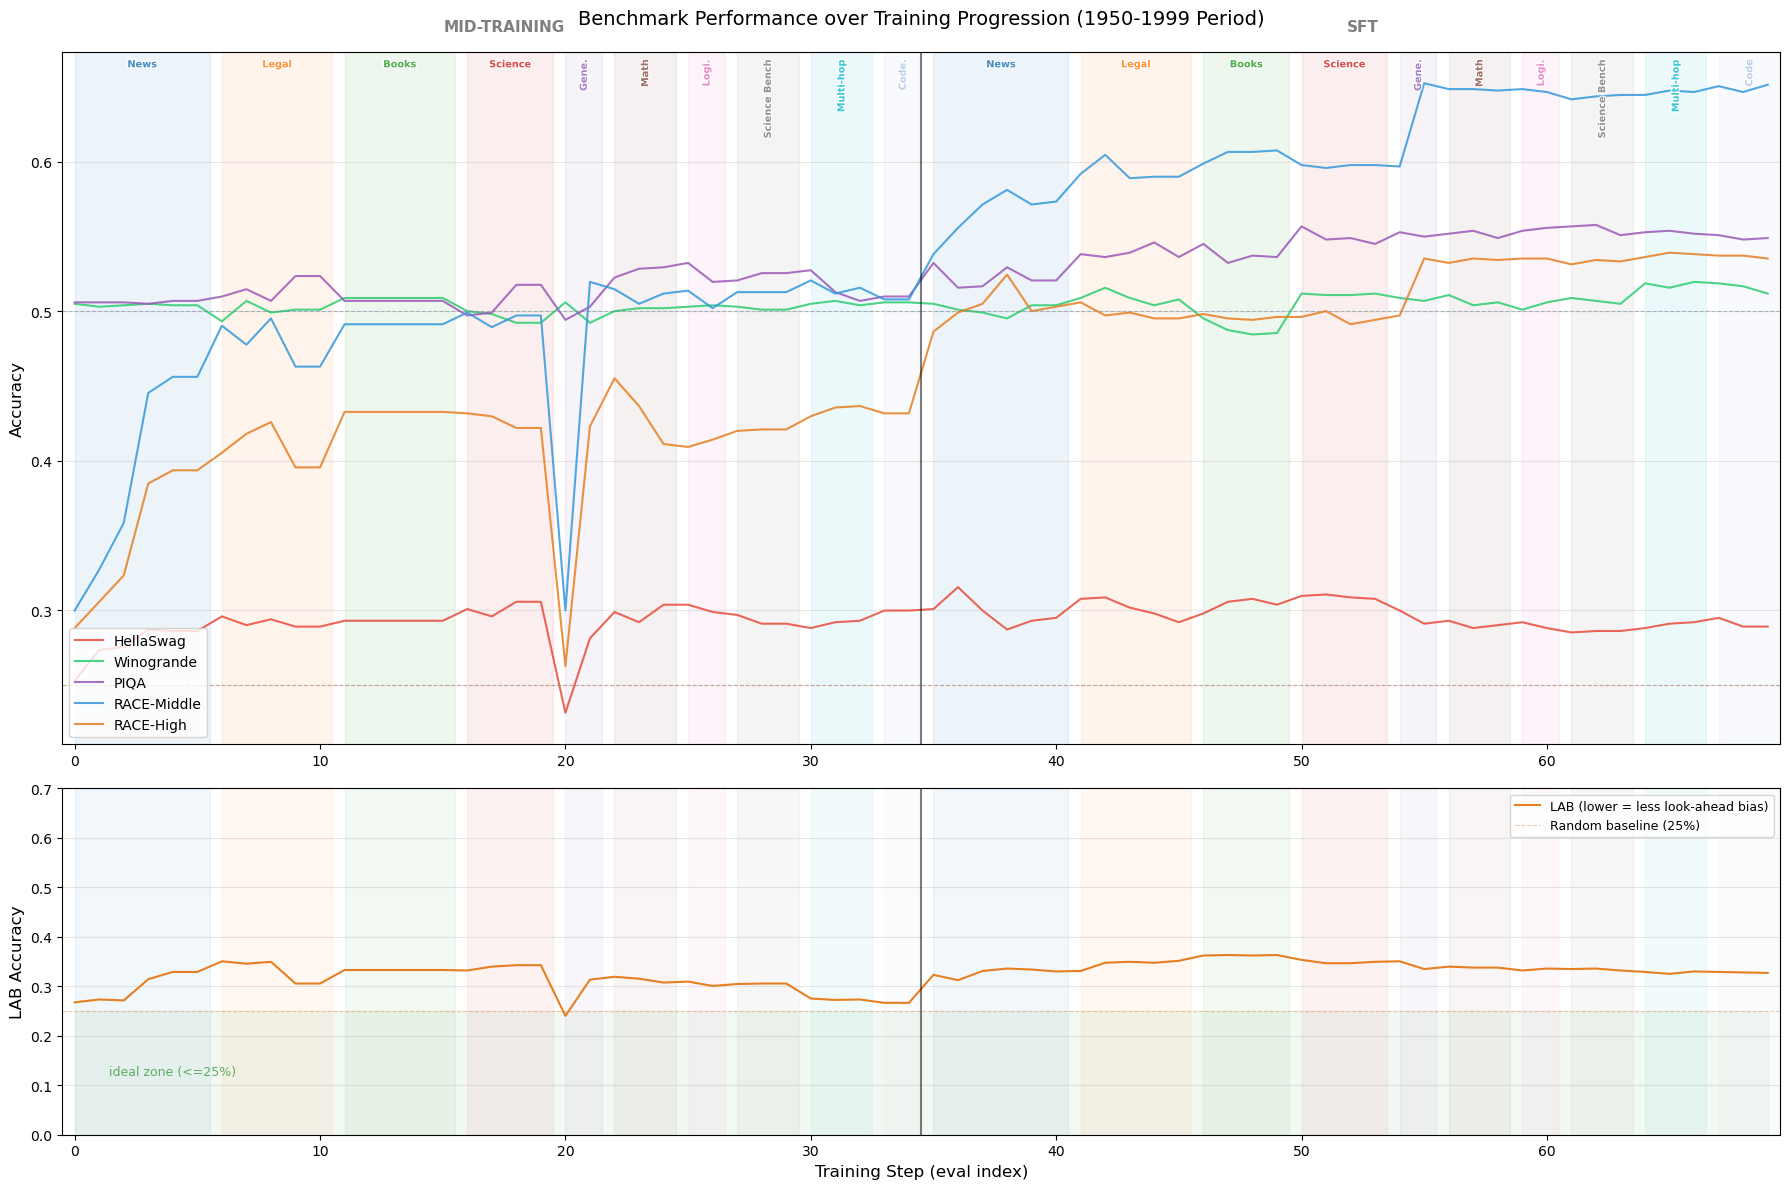

Saved to D:\nanochat_model\1950_1999\report_new1\benchmark_progression.png


In [50]:
# ── Plot 1: Individual Benchmark Accuracy over Training Progression ──

fig, axes = plt.subplots(2, 1, figsize=(18, 12), gridspec_kw={"height_ratios": [3, 1.5]})

# --- Top panel: Standard benchmarks ---
ax = axes[0]

benchmark_colors = {
    "HellaSwag": "#e74c3c",
    "Winogrande": "#2ecc71",
    "PIQA": "#9b59b6",
    "RACE-Middle": "#3498db",
    "RACE-High": "#e67e22",
}
baselines = {
    "HellaSwag": 0.25, "Winogrande": 0.50, "PIQA": 0.50,
    "RACE-Middle": 0.25, "RACE-High": 0.25,
}

for bm in BENCHMARKS:
    if bm in df_seq.columns:
        ax.plot(df_seq["eval_idx"], df_seq[bm], label=bm,
                color=benchmark_colors[bm], linewidth=1.5, alpha=0.85)
        # Random baseline
        ax.axhline(y=baselines[bm], color=benchmark_colors[bm],
                   linestyle="--", alpha=0.3, linewidth=0.8)

# Add phase boundary (MID → SFT)
mid_count = len(df_seq[df_seq["source"] == "mid"])
if mid_count > 0:
    ax.axvline(x=mid_count - 0.5, color="black", linestyle="-", alpha=0.5, linewidth=1.5)

# Collect shaded region info for labeling
region_infos = []  # list of (start_x, end_x, color, domain, source)
prev_domain = None
group_start = 0
for i, row in df_seq.iterrows():
    cur_domain = row["phase_domain"]
    if cur_domain != prev_domain and prev_domain is not None:
        end_x = row["eval_idx"] - 0.5
        region_infos.append((group_start, end_x,
                             df_seq.iloc[i-1]["color"],
                             df_seq.iloc[i-1]["domain"],
                             df_seq.iloc[i-1]["source"]))
        ax.axvspan(group_start, end_x, alpha=0.08,
                   color=df_seq.iloc[i-1]["color"])
        group_start = row["eval_idx"]
    prev_domain = cur_domain
# Last group
end_x = df_seq["eval_idx"].iloc[-1] + 0.5
region_infos.append((group_start, end_x,
                     df_seq.iloc[-1]["color"],
                     df_seq.iloc[-1]["domain"],
                     df_seq.iloc[-1]["source"]))
ax.axvspan(group_start, end_x, alpha=0.08,
           color=df_seq.iloc[-1]["color"])

# Add domain labels at the top of each shaded region
y_top = ax.get_ylim()[1]
for start_x, end_x, color, domain, source in region_infos:
    mid_x = (start_x + end_x) / 2
    label_text = domain
    # For narrow regions (≤2 eval points), use abbreviated labels
    width = end_x - start_x
    if width < 2.5:
        label_text = domain[:4] + "."  # abbreviate
    ax.text(mid_x, y_top - 0.005, label_text,
            ha="center", va="top", fontsize=7, fontweight="bold",
            color=color, alpha=0.8, rotation=90 if width < 3 else 0,
            path_effects=[pe.withStroke(linewidth=2, foreground="white")])

# MID / SFT labels above the domain labels
if mid_count > 0:
    ax.text(mid_count / 2, y_top + 0.012, "MID-TRAINING",
            ha="center", va="bottom", fontsize=11, fontweight="bold", color="black", alpha=0.5)
ax.text(mid_count + (len(df_seq) - mid_count) / 2, y_top + 0.012, "SFT",
        ha="center", va="bottom", fontsize=11, fontweight="bold", color="black", alpha=0.5)

ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Benchmark Performance over Training Progression (1950-1999 Period)", fontsize=14, pad=20)
ax.legend(loc="lower left", fontsize=10)
ax.set_xlim(-0.5, len(df_seq) - 0.5)
ax.grid(axis="y", alpha=0.3)

# --- Bottom panel: LAB accuracy (lower = better) ---
ax2 = axes[1]
ax2.plot(df_seq["eval_idx"], df_seq["LAB"], color="#e67e22", linewidth=1.5, label="LAB (lower = less look-ahead bias)")
ax2.axhline(y=0.25, color="#e67e22", linestyle="--", alpha=0.4, linewidth=0.8, label="Random baseline (25%)")
if mid_count > 0:
    ax2.axvline(x=mid_count - 0.5, color="black", linestyle="-", alpha=0.5, linewidth=1.5)
ax2.fill_between(df_seq["eval_idx"], 0, 0.25, alpha=0.05, color="green")
ax2.text(len(df_seq) * 0.02, 0.12, "ideal zone (<=25%)", fontsize=9, color="green", alpha=0.6)

# Add same shaded regions to LAB panel
for start_x, end_x, color, domain, source in region_infos:
    ax2.axvspan(start_x, end_x, alpha=0.06, color=color)

ax2.set_xlabel("Training Step (eval index)", fontsize=12)
ax2.set_ylabel("LAB Accuracy", fontsize=12)
ax2.legend(loc="upper right", fontsize=9)
ax2.set_xlim(-0.5, len(df_seq) - 0.5)
ax2.set_ylim(0, 0.7)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(REPORT_DIR / "benchmark_progression.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {REPORT_DIR / 'benchmark_progression.png'}")

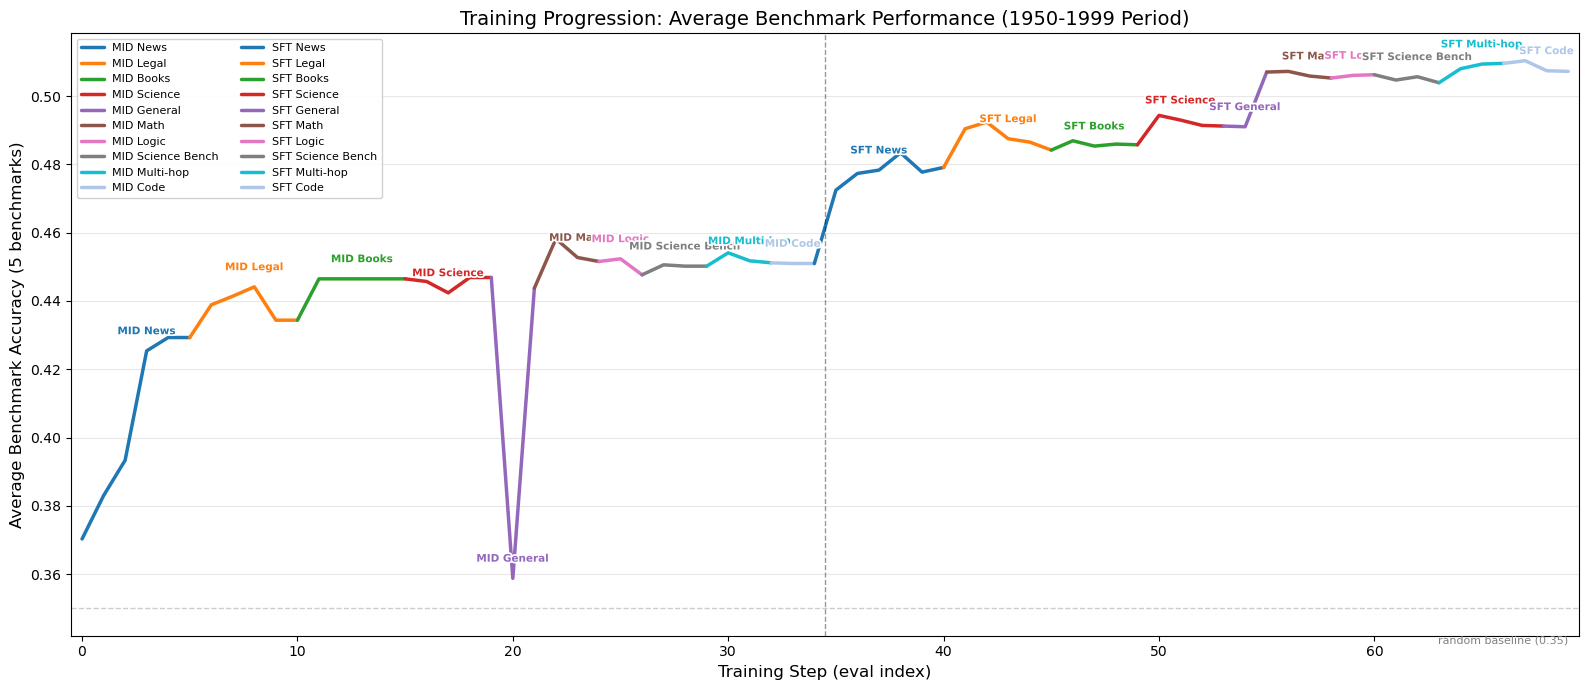

Saved to D:\nanochat_model\1950_1999\report_new1\composite_progression.png


In [51]:
# ── Plot 2: Phase-colored composite curve (like the reference image) ──
# Compute average benchmark accuracy (excluding LAB)

df_seq["avg_benchmark"] = df_seq[BENCHMARKS].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 7))

# Plot each domain segment with its own color
prev_domain = None
seg_start = 0
segments = []  # (start, end, color, label, source)

for i, row in df_seq.iterrows():
    cur_domain = row["phase_domain"]
    if cur_domain != prev_domain and prev_domain is not None:
        segments.append((seg_start, row["eval_idx"] - 1, df_seq.loc[i-1, "color"],
                         df_seq.loc[i-1, "domain"], df_seq.loc[i-1, "source"]))
        seg_start = row["eval_idx"] - 1  # overlap by 1 for continuity
    prev_domain = cur_domain
# Last segment
segments.append((seg_start, df_seq["eval_idx"].iloc[-1], df_seq.iloc[-1]["color"],
                 df_seq.iloc[-1]["domain"], df_seq.iloc[-1]["source"]))

# Draw each segment
labeled_domains = set()
for start, end, color, domain, source in segments:
    mask = (df_seq["eval_idx"] >= start) & (df_seq["eval_idx"] <= end)
    sub = df_seq[mask]
    phase_label = f"{source.upper()} {domain}"
    lbl = phase_label if phase_label not in labeled_domains else None
    labeled_domains.add(phase_label)
    ax.plot(sub["eval_idx"], sub["avg_benchmark"],
            color=color, linewidth=2.5, label=lbl, solid_capstyle="round")

# Add segment labels at midpoints (like the reference image)
for start, end, color, domain, source in segments:
    mask = (df_seq["eval_idx"] >= start) & (df_seq["eval_idx"] <= end)
    sub = df_seq[mask]
    if len(sub) >= 2:
        mid_idx = sub["eval_idx"].iloc[len(sub) // 2]
        mid_val = sub["avg_benchmark"].iloc[len(sub) // 2]
        label_text = f"{source.upper()} {domain}"
        ax.annotate(label_text, xy=(mid_idx, mid_val),
                    xytext=(0, 12), textcoords="offset points",
                    fontsize=7.5, ha="center", color=color, fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

# Phase boundary
if mid_count > 0:
    ax.axvline(x=mid_count - 0.5, color="black", linestyle="--", alpha=0.4, linewidth=1)

# Random baseline for average of all benchmarks
avg_baseline = np.mean([baselines[bm] for bm in BENCHMARKS])
ax.axhline(y=avg_baseline, color="gray", linestyle="--", alpha=0.4, linewidth=1)
ax.text(len(df_seq) - 1, avg_baseline - 0.008, f"random baseline ({avg_baseline:.2f})",
        ha="right", va="top", fontsize=8, color="gray")

ax.set_xlabel("Training Step (eval index)", fontsize=12)
ax.set_ylabel(f"Average Benchmark Accuracy ({len(BENCHMARKS)} benchmarks)", fontsize=12)
ax.set_title("Training Progression: Average Benchmark Performance (1950-1999 Period)", fontsize=14)
ax.set_xlim(-0.5, len(df_seq) - 0.5)
ax.grid(axis="y", alpha=0.3)

# Compact legend
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.9)

plt.tight_layout()
plt.savefig(REPORT_DIR / "composite_progression.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {REPORT_DIR / 'composite_progression.png'}")

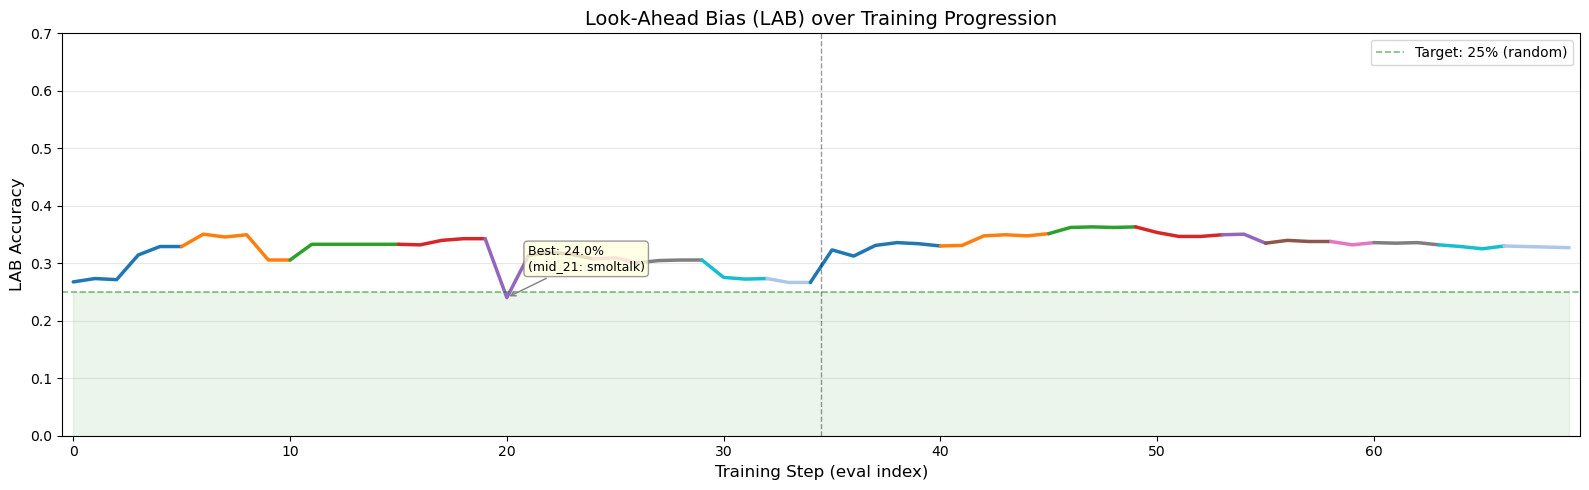

Saved to D:\nanochat_model\1950_1999\report_new1\lab_progression.png


In [52]:
# ── Plot 3: LAB accuracy standalone (to highlight look-ahead bias reduction) ──

fig, ax = plt.subplots(figsize=(16, 5))

# Plot LAB with domain coloring
for start, end, color, domain, source in segments:
    mask = (df_seq["eval_idx"] >= start) & (df_seq["eval_idx"] <= end)
    sub = df_seq[mask]
    ax.plot(sub["eval_idx"], sub["LAB"], color=color, linewidth=2.5, solid_capstyle="round")

ax.axhline(y=0.25, color="green", linestyle="--", alpha=0.5, linewidth=1.2, label="Target: 25% (random)")
ax.axvline(x=mid_count - 0.5, color="black", linestyle="--", alpha=0.4, linewidth=1)
ax.fill_between(df_seq["eval_idx"], 0, 0.25, alpha=0.08, color="green")

# Annotate min LAB
min_lab_idx = df_seq["LAB"].idxmin()
min_lab_row = df_seq.loc[min_lab_idx]
ax.annotate(f"Best: {min_lab_row['LAB']:.1%}\n({min_lab_row['label']})",
            xy=(min_lab_row["eval_idx"], min_lab_row["LAB"]),
            xytext=(15, 20), textcoords="offset points",
            fontsize=9, ha="left",
            arrowprops=dict(arrowstyle="->", color="gray", lw=1),
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.8))

ax.set_xlabel("Training Step (eval index)", fontsize=12)
ax.set_ylabel("LAB Accuracy", fontsize=12)
ax.set_title("Look-Ahead Bias (LAB) over Training Progression", fontsize=14)
ax.set_xlim(-0.5, len(df_seq) - 0.5)
ax.set_ylim(0, 0.7)
ax.legend(loc="upper right", fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(REPORT_DIR / "lab_progression.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {REPORT_DIR / 'lab_progression.png'}")

In [ ]:
# ── Summary table: Start vs End of each phase ──

summary_rows = []
for source in ["mid", "sft"]:
    sub = df_seq[df_seq["source"] == source]
    if len(sub) == 0:
        continue
    first = sub.iloc[0]
    last = sub.iloc[-1]
    row_data = {"Phase": source.upper()}
    for bm in BENCHMARKS:
        if bm in first and pd.notna(first[bm]):
            row_data[f"Start {bm}"] = f"{first[bm]:.1%}"
            row_data[f"End {bm}"] = f"{last[bm]:.1%}"
    row_data["Start LAB"] = f"{first['LAB']:.1%}"
    row_data["End LAB"] = f"{last['LAB']:.1%}"
    summary_rows.append(row_data)

# Also show sft_final if available
sft_final = df[df["label"] == "sft_final"]
if len(sft_final) > 0:
    row = sft_final.iloc[0]
    print("=== SFT Final (full eval suite) ===")
    for col in BENCHMARKS + ["SpellingBee", "DyckLanguage", "LAB", "ChatCORE"]:
        if col in row and pd.notna(row[col]):
            print(f"  {col}: {row[col]:.4f}")

# Also show mid_final if available
mid_final = df[df["label"] == "mid_final"]
if len(mid_final) > 0:
    row = mid_final.iloc[0]
    print("=== MID Final (full eval suite) ===")
    for col in BENCHMARKS + ["SpellingBee", "DyckLanguage", "LAB", "ChatCORE"]:
        if col in row and pd.notna(row[col]):
            print(f"  {col}: {row[col]:.4f}")

pd.DataFrame(summary_rows)